# Tutorial on the modified versions of the same template

In this tutorial, we explore the different options that a converter template can present: the protection against exonuclease degradation, and the 3' phosphorylation to prevent polymerase extension.

## I. Protection against exonuclease degradation

In [4]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Get the absolute path to the root directory
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)


from PEN_simulation import PEN_System
from strands import Signal, Drain, Template, Reporter, reverse_complement


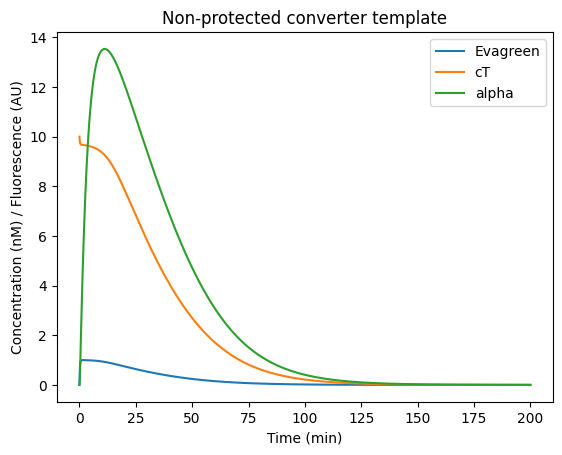

In [5]:
system = PEN_System(temperature=45,                    
                    
                    sodium=0.07,                      
                    magnesium=0.0125,                 

                    concentration_BsmI=300,          
                    concentration_NBI=10,             
                    concentration_pol=30,          
                    concentration_exo=23,              

                    leak=0,                             
                    )



# Define the Signal
alpha=Signal(name="alpha",                              # Name of the Signal
             sequence="CATTCTGGACTG",                   # Sequence of the Signal
             concentration=0,                           # Concentration of the Signal
             protected=False,                           # Is it protected against exonuclease degradation?
             IsDrained=False,                            # Is there a drain potentially deactivating the Signal (checked during simulation)
             plus=0,                                    # Is it a longer version of another Signal?
             minus=0,                                   # Is it a shorter version of another Signal?
             )  

beta=Signal(name="beta",
            sequence="CATTCAGGATCG",                    # Could be the same as alpha at the moment. It's better to use actual sequences for computing actual kinetic rates.
            concentration=100, 
            protected=False, 
            IsDrained=False
            )

system.add_signal(alpha)
system.add_signal(beta)



# Define the Converter Templates        
cT=Template(name="cT",                                 
            sequence="CAGTCCAGAATGCGATCCTGAATG",       
            input=beta,                                
            output=alpha,                              
            concentration=10,                          
            nick="NBI",                                 
            protected=False,                             # The converter is not protected here
            phosphorylated=False,                            
            irreversible=False,                          # The converter is reversible
            leak=5e-6                                   
            )
system.add_template(cT)

t=np.linspace(0,200,1001)
y=system.solve_system(t)

fluo=system.concentration_list(y,"Evagreen") # extract the solution corresponding to the Evagreen fluorescence
cT_all=system.concentration_list(y,"cT", option="all") 
cT_alpha=system.concentration_list(y,"alpha", option="alone") 

plt.plot(t,fluo, label="Evagreen")
plt.plot(t,cT_all, label="cT")
plt.plot(t,cT_alpha, label="alpha")

plt.legend()
plt.xlabel("Time (min)")
plt.ylabel("Concentration (nM) / Fluorescence (AU)")
plt.title("Non-protected converter template")
plt.show()


The exonuclease degrades the template, as it is not protected. After some time there is no more template, and therefore no more output strand (that is not protected)

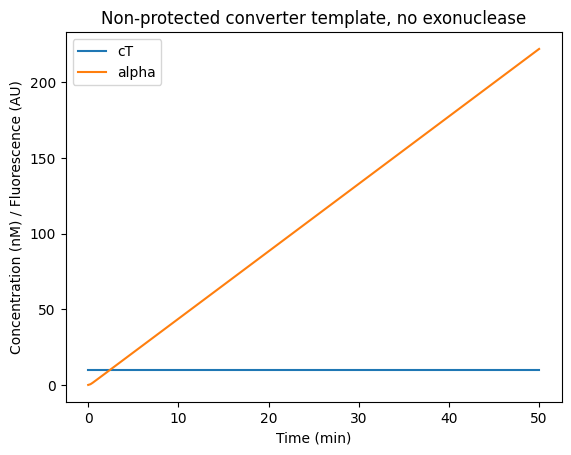

In [6]:
# Non-protected, but no polymerase

system = PEN_System(temperature=45,                    
                    
                    sodium=0.07,                      
                    magnesium=0.0125,                 

                    concentration_BsmI=300,          
                    concentration_NBI=10,             
                    concentration_pol=30,          
                    concentration_exo=0,              

                    leak=0,                             
                    )



# Define the Signal
alpha=Signal(name="alpha",                              # Name of the Signal
             sequence="CATTCTGGACTG",                   # Sequence of the Signal
             concentration=0,                           # Concentration of the Signal
             protected=False,                           # Is it protected against exonuclease degradation?
             IsDrained=False,                            # Is there a drain potentially deactivating the Signal (checked during simulation)
             plus=0,                                    # Is it a longer version of another Signal?
             minus=0,                                   # Is it a shorter version of another Signal?
             )  

beta=Signal(name="beta",
            sequence="CATTCAGGATCG",                    # Could be the same as alpha at the moment. It's better to use actual sequences for computing actual kinetic rates.
            concentration=100, 
            protected=False, 
            IsDrained=False
            )

system.add_signal(alpha)
system.add_signal(beta)



# Define the Converter Templates        
cT=Template(name="cT",                                 
            sequence="CAGTCCAGAATGCGATCCTGAATG",       
            input=beta,                                
            output=alpha,                              
            concentration=10,                          
            nick="NBI",                                 
            protected=False,                             # The converter is not protected here
            phosphorylated=False,                            
            irreversible=False,                          # The converter is reversible
            leak=5e-6                                   
            )
system.add_template(cT)

t=np.linspace(0,50,201)
y=system.solve_system(t)

cT_all=system.concentration_list(y,"cT", option="all") 
cT_alpha=system.concentration_list(y,"alpha", option="alone") 

plt.plot(t,cT_all, label="cT")
plt.plot(t,cT_alpha, label="alpha")

plt.legend()
plt.xlabel("Time (min)")
plt.ylabel("Concentration (nM) / Fluorescence (AU)")
plt.title("Non-protected converter template, no exonuclease")
plt.show()


If there is no exonuclease, even if the template is not protected, there is no degradation, and the output strand is linearly produced

## II. Non-phosphorylated templates

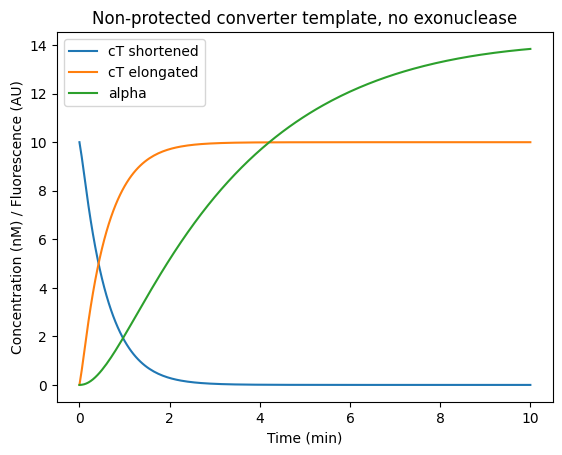

PEN System Summary
Temperature: 45 °C
Leak rate: 0
Sodium concentration: 0.07 M
Magnesium concentration: 0.0125 M

--------------------------------------------------
List of Signals
--------------------------------------------------
Signal 1:
Signal: alpha
sequence: CATTCTGGACTG
concentration: 0 nM
protected: False
is drained: False

Signal 2:
Signal: beta
sequence: CATTCAGGATCG
concentration: 100 nM
protected: False
is drained: False


--------------------------------------------------
List of Templates
--------------------------------------------------
Template 1:
Template: cT
concentration: 10 nM
input signal: beta
output signal: alpha
sequence: CAGTCCAGAATGCGATCCTGAA
protected: True
phosphorylated: False
nick: NBI
irreversible: False
leak: 5e-06

Template 2:
Template: cT_elongated
concentration: 0 nM
input signal: beta
output signal: alpha
sequence: CAGTCCAGAATGCGATCCTGAATG
protected: True
phosphorylated: False
nick: NBI
irreversible: False
leak: None




In [7]:
# Non-phosphorylated 

system = PEN_System(temperature=45,                    
                    
                    sodium=0.07,                      
                    magnesium=0.0125,                 

                    concentration_BsmI=300,          
                    concentration_NBI=10,             
                    concentration_pol=30,          
                    concentration_exo=23,              

                    leak=0,                             
                    )



# Define the Signal
alpha=Signal(name="alpha",                              # Name of the Signal
             sequence="CATTCTGGACTG",                   # Sequence of the Signal
             concentration=0,                           # Concentration of the Signal
             protected=False,                           # Is it protected against exonuclease degradation?
             IsDrained=False,                            # Is there a drain potentially deactivating the Signal (checked during simulation)
             plus=0,                                    # Is it a longer version of another Signal?
             minus=0,                                   # Is it a shorter version of another Signal?
             )  

beta=Signal(name="beta",
            sequence="CATTCAGGATCG",                    # Could be the same as alpha at the moment. It's better to use actual sequences for computing actual kinetic rates.
            concentration=100, 
            protected=False, 
            IsDrained=False
            )

system.add_signal(alpha)
system.add_signal(beta)



# Define the Converter Templates        
cT=Template(name="cT",                                 
            sequence=reverse_complement(alpha.sequence)+reverse_complement(beta.sequence)[:-2],       
            input=beta,                                
            output=alpha,                              
            concentration=10,                          
            nick="NBI",                                 
            protected=True,                             
            phosphorylated=False,                        # The converter is not phosphorylated here
            irreversible=False,                          # The converter is reversible
            leak=5e-6                                   
            )

system.add_template(cT)

t=np.linspace(0,10,201)
y=system.solve_system(t)

cT_all=system.concentration_list(y,"cT", option="all") 
cT_elongated_all=system.concentration_list(y,"cT_elongated", option="all") 
cT_alpha=system.concentration_list(y,"alpha", option="alone") 

plt.plot(t,cT_all, label="cT shortened")
plt.plot(t,cT_elongated_all, label="cT elongated")
plt.plot(t,cT_alpha, label="alpha")

plt.legend()
plt.xlabel("Time (min)")
plt.ylabel("Concentration (nM) / Fluorescence (AU)")
plt.title("Non-protected converter template, no exonuclease")
plt.show()

system.print()


If the converter template is 3' shortened but not phosphorylated, the polymerase extends it into the full version one.

There is no need to define the elongated reporter template, as it handled by PENSIM.